In [2]:
# ==============================================================================
# Cell 1: Environment Setup & Imports
# ==============================================================================
%load_ext autoreload
%autoreload 2

import os
import cv2
import math
import numpy as np
import pandas as pd
from skimage.measure import label, regionprops
from cellpose.models import CellposeModel

# Import our custom package modules
from src.metadata_utilities import *
from src.image_segmentation_ai import *
from src.quantification_math import *
from src.center_crop_quant import *

# Hardware & Model Configuration
MICRONS_PER_PIXEL = 0.645
USE_GPU = True
CUSTOM_MODEL_PATH = "/Users/nadiaayad/Library/CloudStorage/Box-Box/Nadia_WeaverLab/Data/Experiments/Density/20210413_P43/train/models/highdensity_cpsam_20260612_115914"

# Folder Identifiers
# 1. Define the Channel Folders
outline_folder="3_Channel_3" # Outline will be used to define colony boundaries
quant_folder="2_Channel_2"   # Quantifying folder will be thresholded with triangle
nuc_folder="3_Channel_3"     # Nuclear folder will be thresholded using a fine-tuned Cellpose model defined in the previous cell
# 2. Define the Filename Identifiers
outline_file_token="_Ch3"
quant_file_token="_Ch2"
nuc_file_token="_Ch3"
# 3. Define the Spreadsheet Labels
quant_label="NucView"
nuc_label="T-rep"
mask_label="T-rep"

print("Loading Cellpose Model...")
cellpose_model = CellposeModel(gpu=USE_GPU, pretrained_model=CUSTOM_MODEL_PATH)
print("Model loaded and pipeline ready to run")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading Cellpose Model...
Model loaded and pipeline ready to run


In [4]:
#CleavCasp3_Ctrl
if __name__ == "__main__":
    df_results_custom = run_unified_metadata_and_quantification(cellpose_model,
                                                                outline_folder, quant_folder, nuc_folder, 
                                                                outline_file_token, quant_file_token, nuc_file_token,
                                                                quant_label, nuc_label, mask_label)

Starting Unified Analysis Workflow Engine under: /Users/nadiaayad/Library/CloudStorage/Box-Box/Nadia_WeaverLab/Data/Experiments/PacMan_NucView_0h_TFM_48h/48h
Found 3 datasets containing 17 total images to process.


Pipeline Progress:   0%|          | 0/17 [00:00<?, ?img/s]

Loading FastSAM Model...


IndexError: index 0 is out of bounds for dimension 0 with size 0

--- SUMMARY STATISTICS: top5% by condition_shape ---
                 count       mean        std     median
condition_shape                                        
ctrl Circle         17  33.284012  12.744555  28.322658
ctrl Square         18  44.575209  21.412418  38.906406
ctrl Triangle       24  46.374862  16.018606  44.646879

------------------------------------------------------------
One-Way ANOVA: p-value = 4.774331e-02
  Result: SIGNIFICANT variance. Running Tukey HSD...
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1       group2    meandiff p-adj   lower    upper  reject
-----------------------------------------------------------------
ctrl Circle   ctrl Square  11.2912 0.1325  -2.5982 25.1806  False
ctrl Circle ctrl Triangle  13.0909 0.0485   0.0721 26.1096   True
ctrl Square ctrl Triangle   1.7997 0.9389 -11.0057  14.605  False
-----------------------------------------------------------------


/Users/nadiaayad/Documents/GitHub/colony-quant/src/quantification_math.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=analysis_df, x=x_variable, y=y_variable, order=groups,


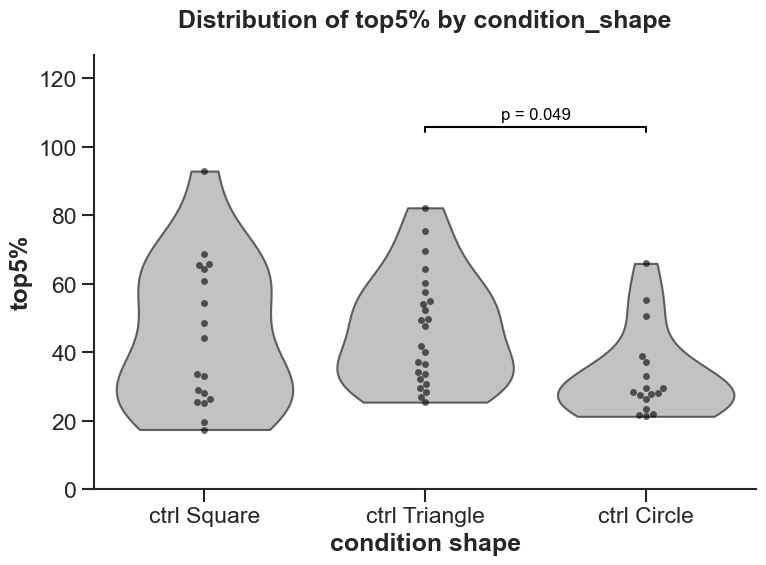

/Users/nadiaayad/Documents/GitHub/colony-quant/src/quantification_math.py:117: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=analysis_df, x=x_variable, y=y_variable, order=groups,


--- SUMMARY STATISTICS: mean by condition_shape ---
                 count       mean       std     median
condition_shape                                       
ctrl Circle         17   8.386331  2.212657   7.765402
ctrl Square         18  10.899418  4.391222  10.127896
ctrl Triangle       24  10.377167  3.374929   9.989515

------------------------------------------------------------
One-Way ANOVA: p-value = 8.283298e-02


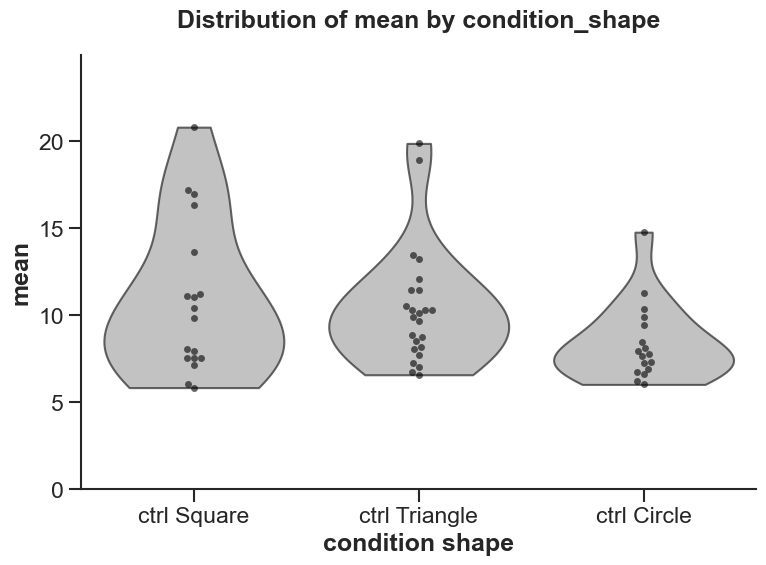

--- K-S DISTRIBUTION STATS (Reference: ctrl Circle) ---
rocki Circle vs ctrl Circle: K-S stat = 0.5833 | p-value = 1.151551e-02
jasplak Circle vs ctrl Circle: K-S stat = 0.7321 | p-value = 2.546233e-04
smifh2 Circle vs ctrl Circle: K-S stat = 0.5583 | p-value = 6.930960e-03
cytd Circle vs ctrl Circle: K-S stat = 0.4875 | p-value = 2.491032e-01
unc2541 Circle vs ctrl Circle: K-S stat = 0.8125 | p-value = 1.085019e-03
pm PacMan vs ctrl Circle: K-S stat = 0.8125 | p-value = 7.315040e-04


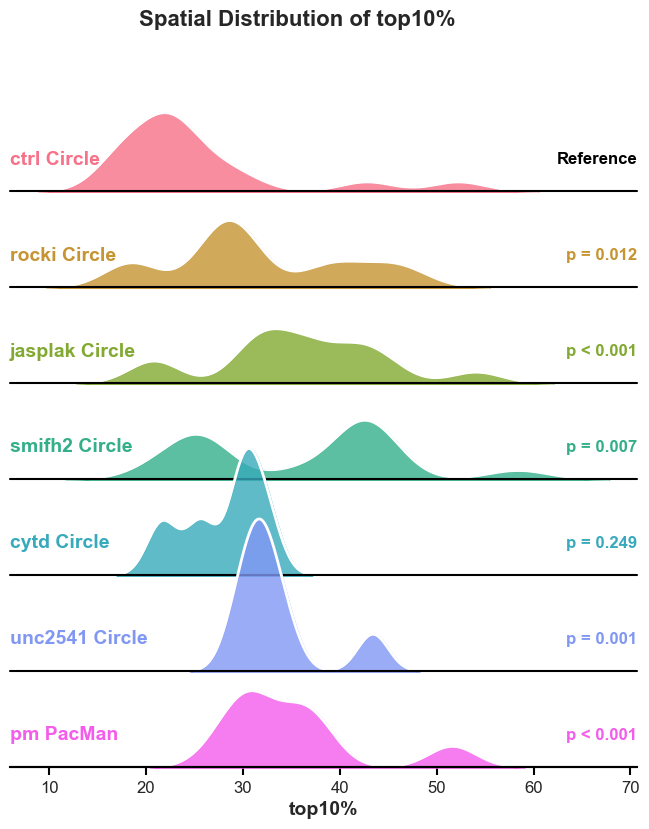

In [92]:
#TFM plotting
from src.quantification_math import *
#Running stats and plotting

master_summary_df = pd.read_csv("/Users/nadiaayad/Library/CloudStorage/Box-Box/Nadia_WeaverLab/Data/Experiments/TFM_All/TractionData.csv")

#  new combined category column in your dataframe
master_summary_df['condition_shape'] = master_summary_df['condition'] + " " + master_summary_df['shape']
# 2. Define your custom colors
shape_colors = {
    "ctrl": "lightgray",
    "qvd": "#f1c40f",  # A nice PacMan yellow!
    "zvad": "#f2a60f",
    "jasplak": "green",
    "cytd": "blue",
    "rocki": "red", 
    "smifh2":"lightblue", 
    "blebb":"pink", 
    "unc2541":"magenta",
    "pm PacMan":"orange", 
    "ctrl Circle":"darkgrey", 
    "ctrl Square":"darkgrey",
    "ctrl Triangle":"darkgrey"
}

# new column as X-axis
run_statistical_analysis(
    df=master_summary_df,
    x_variable='condition_shape',                  # <--- Use the new combined column
    y_variable='top5%',
    subset_categories=['ctrl Circle', 'ctrl Square', 'ctrl Triangle'], # <--- Select your specific combos
    custom_palette=shape_colors
)

run_statistical_analysis(
    df=master_summary_df,
    x_variable='condition_shape',                  
    y_variable='mean',
    subset_categories=['ctrl Circle', 'ctrl Square', 'ctrl Triangle'], # <--- Select your specific combos
    custom_palette=shape_colors
)

condition_col = 'condition_shape'
distance_col = 'top10%'
control_group = 'ctrl Circle'
subset_categories = ['ctrl Circle', 'rocki Circle', 'jasplak Circle', 'smifh2 Circle', 'cytd Circle', 'unc2541 Circle', 'pm PacMan']
#custom_palette
#title = 
#save_filename = 
plot_spatial_ridgeline(master_summary_df, condition_col, 
                       distance_col, control_group, subset_categories, title=None, save_filename="ridgeline_output")

--- K-S DISTRIBUTION STATS (Reference: Ctrl) ---
Cytd vs Ctrl: K-S stat = 0.2532 | p-value = 5.610406e-01
Jasplak vs Ctrl: K-S stat = 0.4167 | p-value = 2.197076e-01


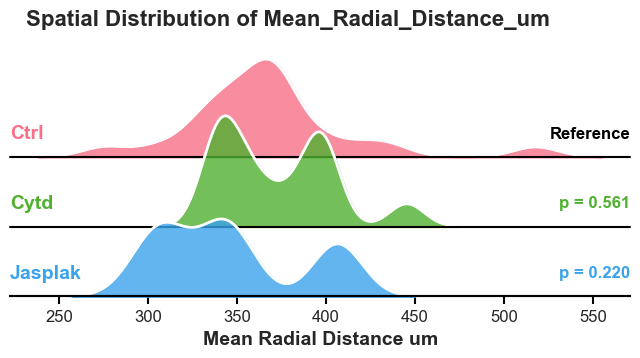

--- K-S DISTRIBUTION STATS (Reference: Ctrl) ---
SMIFH2 vs Ctrl: K-S stat = 0.0393 | p-value = 0.000000e+00
Jasplak vs Ctrl: K-S stat = 0.1362 | p-value = 0.000000e+00


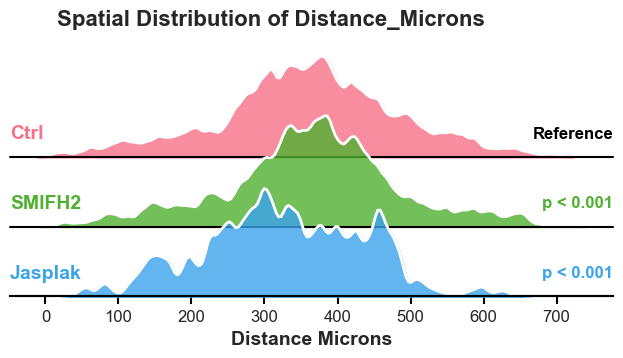

In [73]:
from src.quantification_math import *
df = pd.read_excel('/Users/nadiaayad/Library/CloudStorage/Box-Box/Nadia_WeaverLab/Data/Experiments/CleavedCasp3/combined_metadata_quantification_summary.xlsx')
condition_col = 'Treatment'
distance_col = 'Mean_Radial_Distance_um'
control_group = 'Ctrl'
subset_categories = ['Ctrl', 'Cytd', 'Jasplak']
#custom_palette
#title = 
#save_filename = 
plot_spatial_ridgeline(df, condition_col, 
                       distance_col, control_group, subset_categories, title=None, save_filename="ridgeline_output")


df2 = pd.read_csv('/Users/nadiaayad/Library/CloudStorage/Box-Box/Nadia_WeaverLab/Data/Experiments/CleavedCasp3/colony_radial_distances_raw_distribution.csv')
condition_col = 'Condition_Group'
distance_col = 'Distance_Microns'
control_group = 'Ctrl'
subset_categories = ['Ctrl', 'SMIFH2', 'Jasplak']
#custom_palette
#title = 
#save_filename = 
plot_spatial_ridgeline(df2, condition_col, 
                       distance_col, control_group, subset_categories, title=None, save_filename="ridgeline_output")